In [1]:
import pandas as pd
import random

education_levels = ['Bachelors', 'Masters', 'PhD']
job_roles = [
    'Intern', 'Junior Developer', 'Software Engineer', 'Senior Developer',
    'Data Analyst', 'Data Scientist', 'QA Engineer', 'Product Manager',
    'Team Lead', 'Manager', 'Senior Manager', 'Director'
]

dataset = []

for i in range(120):
    age = random.randint(21, 55)
    experience = max(0, age - random.randint(21, 27))
    education = random.choices(education_levels, weights=[0.5, 0.3, 0.2])[0]
    job = random.choice(job_roles)
    hours = random.randint(38, 55)

    salary = 20000 + (experience * 4000)

    if education == 'Masters':
        salary += 15000
    elif education == 'PhD':
        salary += 30000

    if 'Senior' in job:
        salary += 25000
    elif 'Manager' in job:
        salary += 40000
    elif 'Director' in job:
        salary += 60000
    elif 'Intern' in job:
        salary -= 10000

    if hours > 45:
        salary += 5000

    salary += random.randint(-7000, 7000)

    dataset.append([age, education, experience, job, hours, salary])

df = pd.DataFrame(dataset, columns=[
    'Age', 'Education', 'Experience', 'JobRole', 'HoursPerWeek', 'Salary'
])

print(df.head())

   Age  Education  Experience          JobRole  HoursPerWeek  Salary
0   50  Bachelors          26     Data Analyst            38  126161
1   54        PhD          32  Product Manager            51  223749
2   48  Bachelors          23          Manager            41  150671
3   46        PhD          20      QA Engineer            43  130659
4   51    Masters          29   Data Scientist            47  161425


# Basic EDA

In [19]:
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Education     120 non-null    int64
 2   Experience    120 non-null    int64
 3   JobRole       120 non-null    int64
 4   HoursPerWeek  120 non-null    int64
 5   Salary        120 non-null    int64
dtypes: int64(6)
memory usage: 5.8 KB
None


In [20]:

print("Statistical Summary:")
print(df.describe())


Statistical Summary:
              Age  Education  Experience     JobRole  HoursPerWeek  \
count  120.000000  120.00000  120.000000  120.000000    120.000000   
mean    39.558333    0.65000   15.725000    5.766667     46.900000   
std      9.923062    0.79547    9.654504    3.134877      5.223412   
min     21.000000    0.00000    0.000000    0.000000     38.000000   
25%     32.000000    0.00000    7.750000    3.750000     42.750000   
50%     41.000000    0.00000   16.000000    6.000000     47.000000   
75%     48.000000    1.00000   24.000000    8.250000     51.000000   
max     55.000000    2.00000   34.000000   11.000000     55.000000   

              Salary  
count     120.000000  
mean   111623.225000  
std     44000.205608  
min     19368.000000  
25%     78089.750000  
50%    111708.500000  
75%    148846.250000  
max    223749.000000  


In [21]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age             0
Education       0
Experience      0
JobRole         0
HoursPerWeek    0
Salary          0
dtype: int64


# Visualizations / Summaries

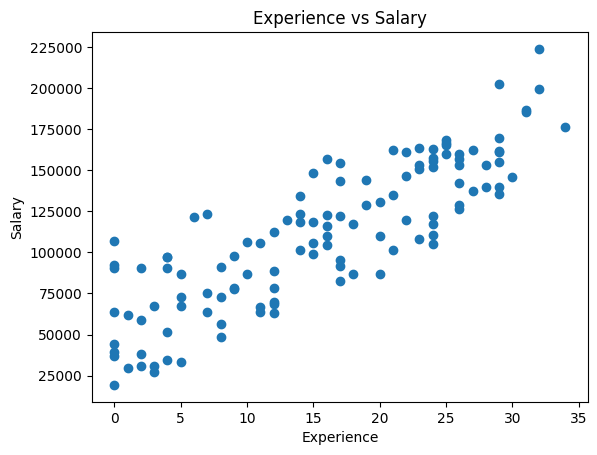

In [5]:
import matplotlib.pyplot as plt

# Experience vs Salary
plt.scatter(df['Experience'], df['Salary'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

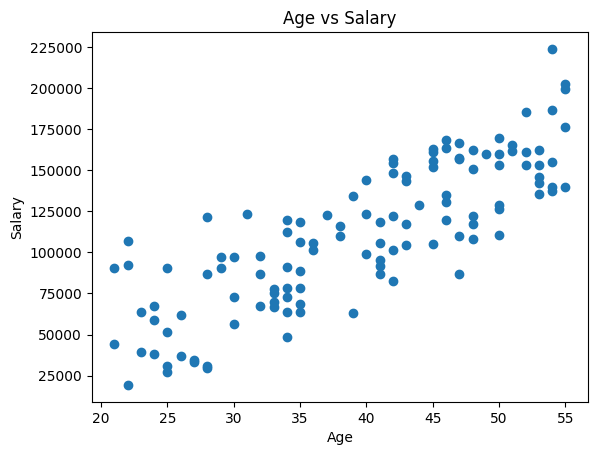

In [6]:
# Age vs Salary
plt.scatter(df['Age'], df['Salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

# Data Preprocessing

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['JobRole'] = le.fit_transform(df['JobRole'])
print(df.head())

   Age  Education  Experience  JobRole  HoursPerWeek  Salary
0   50          0          26        0            38  126161
1   54          2          32        6            51  223749
2   48          0          23        5            41  150671
3   46          2          20        7            43  130659
4   51          1          29        1            47  161425


# Supervised Learning

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Implement 2 Algorithms

In [13]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [15]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Comparison + Metrics

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\n Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 18352.882079434345
MSE: 495712083.58367985
R2 Score: 0.6662192157792051

 Random Forest:
MAE: 18808.607083333332
MSE: 512389607.46657085
R2 Score: 0.6549896388032934


# Visualization Comparison

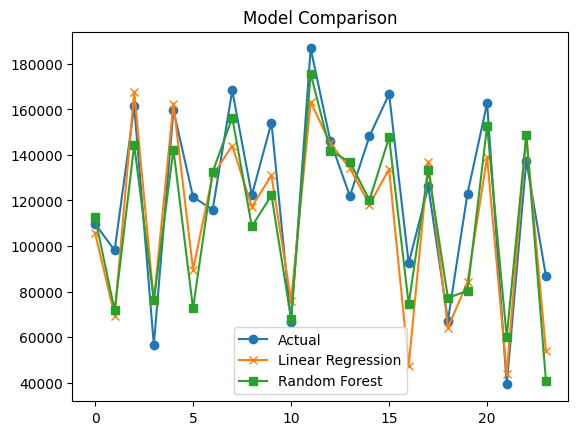

In [22]:
import numpy as np

plt.plot(range(len(y_test)), y_test.values, label="Actual", marker='o')
plt.plot(range(len(y_test)), y_pred_lr, label="Linear Regression", marker='x')
plt.plot(range(len(y_test)), y_pred_rf, label="Random Forest", marker='s')

plt.legend()
plt.title("Model Comparison")
plt.show()